# Exercise 2

In [18]:
import numpy as np
from scipy.stats import beta

epsilon=0.01
heads=50
tails=50

theta_grid = np.arange(0, 1 + epsilon/2, epsilon)

prior = np.ones(len(theta_grid)) / len(theta_grid)

likelihood = (theta_grid**heads) * ((1 - theta_grid)**tails)

unnormalized_posterior = prior * likelihood
discrete_posterior = unnormalized_posterior / np.sum(unnormalized_posterior)

x_continuous = np.linspace(0, 1, 500)
continuous_posterior_pdf = beta.pdf(x_continuous, 1 + heads, 1 + tails)

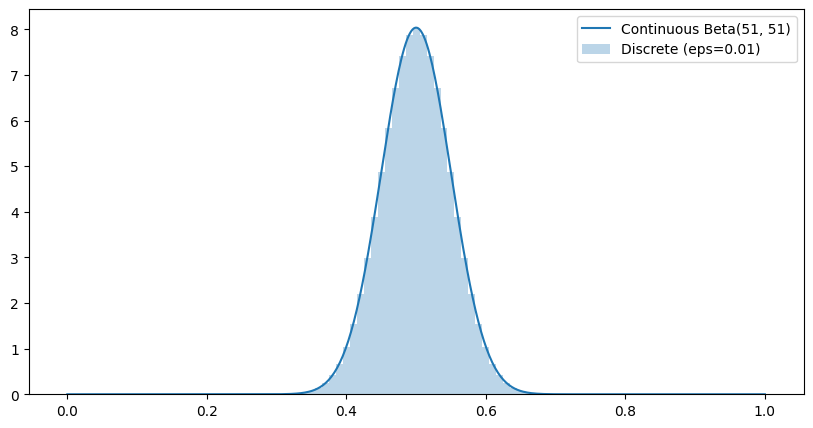

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(theta_grid, discrete_posterior / epsilon, width=epsilon, alpha=0.3, label=f'Discrete (eps={epsilon})')
plt.plot(x_continuous, continuous_posterior_pdf, label='Continuous Beta(51, 51)')
plt.legend()
plt.show()

# Exercise 3 Attempt

Didn't really know how to plot this better. And not really convinced of my answer...

In [43]:
import numpy as np


num_trials=10000
max_t=100
deltas=[0.001, 0.01, 0.1]
theta=0.5
t_values = np.arange(1, max_t + 1)

fail_rates_per_delta = []
for delta in deltas:
  fail_rates = []
  for t in t_values:
      tosses = np.random.binomial(t, theta, size=num_trials)
      empirical_means = tosses / t
      
      confidence = np.sqrt(np.log(2 / delta) / (2 * t))
      failures = np.sum(np.abs(empirical_means - theta) > epsilon)
      fail_rates.append(failures / num_trials)
  fail_rates_per_delta.append(fail_rates)

print(fail_rates_per_delta[0])
print(fail_rates_per_delta[1])
print(fail_rates_per_delta[2])


[np.float64(1.0), np.float64(0.498), np.float64(1.0), np.float64(0.6282), np.float64(1.0), np.float64(0.6915), np.float64(1.0), np.float64(0.7257), np.float64(1.0), np.float64(0.7511), np.float64(1.0), np.float64(0.7759), np.float64(1.0), np.float64(0.7948), np.float64(1.0), np.float64(0.7998), np.float64(1.0), np.float64(0.8172), np.float64(1.0), np.float64(0.8247), np.float64(1.0), np.float64(0.8305), np.float64(1.0), np.float64(0.8353), np.float64(1.0), np.float64(0.8455), np.float64(1.0), np.float64(0.8534), np.float64(1.0), np.float64(0.8616), np.float64(1.0), np.float64(0.8565), np.float64(1.0), np.float64(0.8679), np.float64(1.0), np.float64(0.8671), np.float64(1.0), np.float64(0.8744), np.float64(1.0), np.float64(0.8695), np.float64(1.0), np.float64(0.8817), np.float64(1.0), np.float64(0.8791), np.float64(1.0), np.float64(0.8778), np.float64(1.0), np.float64(0.8863), np.float64(1.0), np.float64(0.8884), np.float64(0.785), np.float64(0.8945), np.float64(0.7874), np.float64(0.890

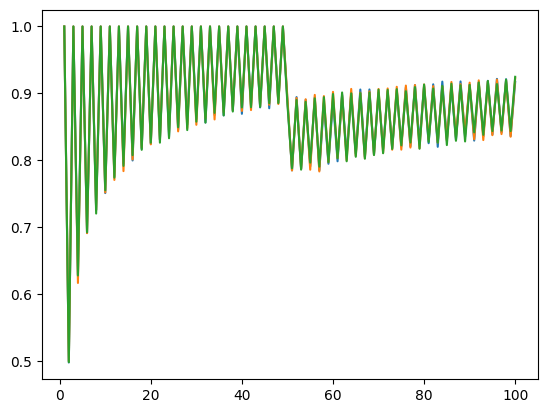

In [45]:
plt.plot(t_values, fail_rates_per_delta[0], label=f'Empirical Failure (δ={0.001})')
plt.plot(t_values, fail_rates_per_delta[1], label=f'Empirical Failure (δ={0.01})')
plt.plot(t_values, fail_rates_per_delta[2], label=f'Empirical Failure (δ={0.1})')
plt.show()